<a href="https://colab.research.google.com/github/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/blob/main/Midterm%20Project/stat_ml_midterm_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from google.colab import files


In [ ]:

df = pd.read_csv('https://raw.githubusercontent.com/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Data/TableF5-1.csv')

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   LFP     753 non-null    int64  
 1   WHRS    753 non-null    int64  
 2   KL6     753 non-null    int64  
 3   K618    753 non-null    int64  
 4   WA      753 non-null    int64  
 5   WE      753 non-null    int64  
 6   WW      753 non-null    float64
 7   RPWG    753 non-null    float64
 8   HHRS    753 non-null    int64  
 9   HA      753 non-null    int64  
 10  HE      753 non-null    int64  
 11  HW      753 non-null    float64
 12  FAMINC  753 non-null    int64  
 13  MTR     753 non-null    float64
 14  WMED    753 non-null    int64  
 15  WFED    753 non-null    int64  
 16  UN      753 non-null    float64
 17  CIT     753 non-null    int64  
 18  AX      753 non-null    int64  
dtypes: float64(5), int64(14)
memory usage: 111.9 KB
None
              LFP         WHRS         KL6        K618      

Shape and Types Audit: all 19 columns are numeric (int64/float64)
No object-type columns detected, so no string cleaning is required
The dirty data issue in this dataset is value-encoded missingness in RPWG (zeros), addressed below

In [ ]:
print(df['RPWG'].value_counts().head(10))
print((df['RPWG'] == 0).sum())

RPWG
0.00    417
2.30     15
2.50     14
4.00     10
3.00     10
4.20      9
5.00      9
2.20      8
9.98      8
6.00      8
Name: count, dtype: int64
417


the 417 0 are considered structurally missing in the dataset I had found because it's meant to represent non-working women. Need to prove it -->

In [ ]:
df['RPWG_missing'] = (df['RPWG'] == 0).astype(int)
print(pd.crosstab(df['RPWG_missing'], df['LFP']))

LFP             0    1
RPWG_missing          
0              10  326
1             315  102


using the cross-tabulation, I see that of the 417 zero-valued RPWG observations, 315 correspond to non-participating women (LFP = 0), consistent with structural missingness —> wages are unobserved because the woman did not enter the labor market. However, 102 participating women (LFP = 1) also report RPWG = 0, suggesting that they were either true zero wages, data entry issues, or a recording inconsistency from the original 1976 survey. Additionally, 10 non-participants carry non-zero RPWG values, possibly reflecting reported reservation wages (aka: how much would you require to enter the labor market). The pattern is predominantly MAR but not perfectly determined by LFP alone. So i'll replace the 417 '0s' as 'not a number' to be like an empty cell for further data analysis

In [ ]:
df.loc[df['RPWG'] == 0, 'RPWG'] = np.nan

In [ ]:
print(df['RPWG'].isna().sum())


417


In [ ]:
print(df['RPWG'].value_counts().head(10))

RPWG
2.30    15
2.50    14
4.00    10
3.00    10
4.20     9
5.00     9
2.20     8
9.98     8
6.00     8
3.25     8
Name: count, dtype: int64


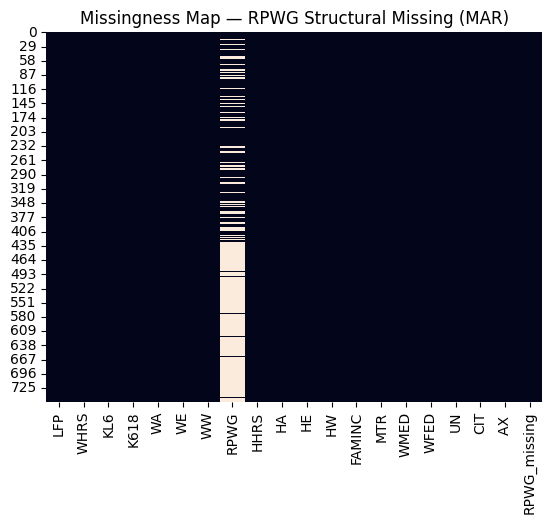

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missingness Map — RPWG Structural Missing (MAR)")
plt.show()

heatmap shows that RPWG is the only variable with missing values. The solid contiguous block of missingness in the lower rows, corresponding to LFP = 0 observations, visually confirms the structural, non-random nature of the missing data. This pattern is inconsistent with MCAR and supports a MAR classification.

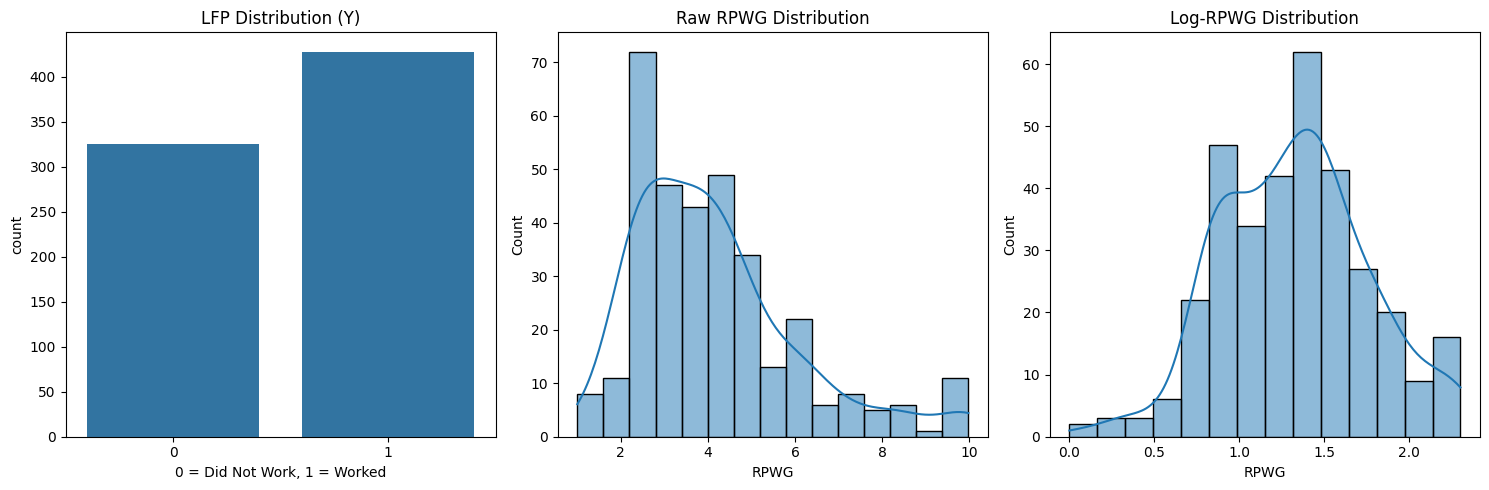

In [ ]:
plt.figure(figsize=(15, 5))

# my Y is LFP which is binary so it cant be a histogram directly, i made it a count plot instead
plt.subplot(1, 3, 1)
sns.countplot(x=df['LFP'])
plt.title("LFP Distribution (Y)")
plt.xlabel("0 = Did Not Work, 1 = Worked")

# Visualizing the log-transformation

plt.subplot(1, 3, 2)
sns.histplot(df['RPWG'].dropna(), kde=True)
plt.title("Raw RPWG Distribution")

plt.subplot(1, 3, 3)
sns.histplot(np.log(df['RPWG'].dropna()), kde=True)
plt.title("Log-RPWG Distribution")

plt.tight_layout()
plt.show()

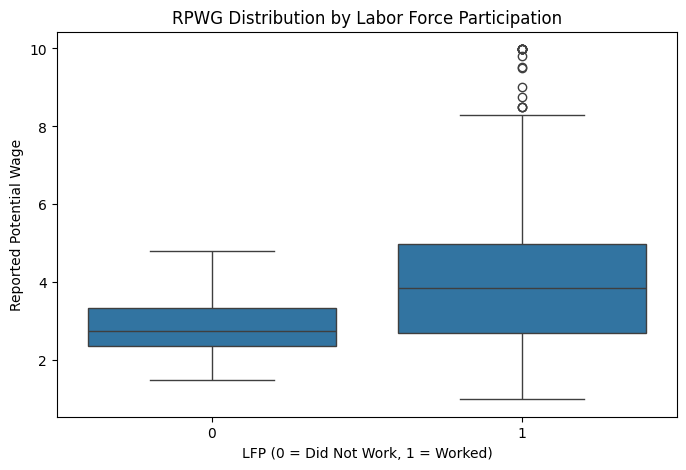

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['LFP'], y=df['RPWG'])

# The LFP=0 group doesn't have many RPWG data due to structural missingness, which is is expected as non-participants largely have no observed wage

plt.title("RPWG Distribution by Labor Force Participation")
plt.xlabel("LFP (0 = Did Not Work, 1 = Worked)")
plt.ylabel("Reported Potential Wage")
plt.show()

In [ ]:
rpwg_clean = df['RPWG'].dropna()

Q1 = rpwg_clean.quantile(0.25)
Q3 = rpwg_clean.quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['RPWG'] < (Q1 - 1.5 * IQR)) | (df['RPWG'] > (Q3 + 1.5 * IQR))]
print(f"Number of outliers: {len(outliers)}")
print(outliers[['RPWG', 'LFP']])

Number of outliers: 18
     RPWG  LFP
7    9.98    1
39   9.53    1
42   9.98    1
56   8.75    1
57   8.25    1
110  9.98    1
133  8.50    1
141  9.98    1
148  9.98    1
161  8.30    1
166  9.98    1
186  9.00    1
239  9.50    1
299  9.80    1
349  9.98    1
368  8.50    1
399  8.50    1
407  9.98    1


# meeting stuff:

In [ ]:
df['log_RPWG'] = np.log(df['RPWG'])

In [ ]:
import statsmodels.formula.api as smf

# baseline
baseline = smf.logit(
    formula='LFP ~ RPWG + WE + KL6 + FAMINC',
    data=df
).fit(cov_type='HC1')  # HC1 = heteroskedasticity-robust SEs

print(baseline.summary())

Optimization terminated successfully.
         Current function value: 0.102562
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                    LFP   No. Observations:                  336
Model:                          Logit   Df Residuals:                      331
Method:                           MLE   Df Model:                            4
Date:                Mon, 23 Mar 2026   Pseudo R-squ.:                  0.2341
Time:                        23:22:27   Log-Likelihood:                -34.461
converged:                       True   LL-Null:                       -44.995
Covariance Type:                  HC1   LLR p-value:                 0.0003070
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.4765      1.715      2.610      0.009       1.115       7.838
RPWG           0.7224      0.

In [ ]:
# marginal effects to get interpretable #'s instead of log ones
marginal_effects = baseline.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:                    LFP
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
RPWG           0.0178      0.008      2.275      0.023       0.002       0.033
WE            -0.0051      0.004     -1.393      0.164      -0.012       0.002
KL6           -0.0495      0.017     -2.835      0.005      -0.084      -0.015
FAMINC     -2.078e-07   7.45e-07     -0.279      0.780   -1.67e-06    1.25e-06


In [ ]:
# Hypothesis: The wage effect on participation differs for women with young children (KL6).
# High childcare costs may mess with the positive wage effect.
# Q: does the wage effect change depending on how many young children a woman has?
# P(LFP=1) = f(β₁·RPWG + β₂·WE + β₃·KL6 + β₄·FAMINC + β₅·RPWG×KL6)


interact_model = smf.logit(
    formula='LFP ~ RPWG + WE + KL6 + FAMINC + RPWG:KL6',
    data=df
).fit(cov_type='HC1')

print(interact_model.summary())
print(interact_model.get_margeff().summary())

Optimization terminated successfully.
         Current function value: 0.101780
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                    LFP   No. Observations:                  336
Model:                          Logit   Df Residuals:                      330
Method:                           MLE   Df Model:                            5
Date:                Mon, 23 Mar 2026   Pseudo R-squ.:                  0.2400
Time:                        23:22:27   Log-Likelihood:                -34.198
converged:                       True   LL-Null:                       -44.995
Covariance Type:                  HC1   LLR p-value:                 0.0006254
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.6969      1.613      2.293      0.022       0.536       6.858
RPWG           0.9398      0.

In [ ]:
df['RPWG'].describe()

,RPWG
count,336.000000
mean,4.145387
std,1.897446
min,1.000000
25%,2.700000
50%,3.800000
75%,4.912500
max,9.980000


# Interpretations

**RPWG**: Holding education, number of young children, and family income constant, a one standard deviation increase in potential wages (~$1.90/hour) is associated with a 4.4 percentage point [ 0.0234 × 1.897 = 0.0444 ] increase in the probability of labor force participation. This result is statistically significant at the 5% level.

**WE**: Holding all else constant, an additional year of education is associated with a 0.48 percentage point [ -0.0048 ]decrease in participation probability, but this effect is not statistically significant. The unexpected negative sign likely reflects multicollinearity — education is already captured through its effect on wages, so RPWG absorbs most of education's influence.

**KL6**: Holding all else constant, each additional child under age 6 is associated with a 3.13 percentage point decrease [ -0.0313 ]in the probability of participation. The direction is consistent with theory, young children impose time costs that reduce labor supply, though the effect does not reach statistical significance, possibly because KL6's effect is partially absorbed by the interaction term.

**FAMINC**: Holding all else constant, family income has a near-zero and statistically insignificant effect on participation. The effect is economically negligible at the margin of one dollar.

**RPWG:KL6**= The interaction term suggests that the positive wage effect on participation weakens by 0.58 percentage points for each additional young child, consistent with the hypothesis that childcare costs dampen wage incentives. This result is not statistically significant but has the theoretically predicted sign.




Omitted Variable Bias: local childcare costs would be helpful to have here because it would allow us to model the dollar price of local childcare since it would directly impact the womans decision to work/wage offers. Also, KL6 only controls for the presence of kids as a time costs, and my interaction test (RPWG:KL6) tests if that affects the wage effect.

In [ ]:
# summary stats
df.groupby('LFP')[['RPWG','WE','KL6','FAMINC']].describe()

# clean version fro report
df.groupby('LFP')[['RPWG','WE','KL6','FAMINC']].agg(['mean','std'])

RPWG                   WE                 KL6            \
         mean       std       mean       std      mean       std   
LFP                                                                
0    2.930000  0.979285  11.796923  2.181995  0.366154  0.636900   
1    4.182669  1.907269  12.658879  2.285376  0.140187  0.391923   

           FAMINC                
             mean           std  
LFP                              
0    21698.052308  12728.148130  
1    24130.422897  11671.255986

In [ ]:
# Table 2
m1 = smf.logit('LFP ~ RPWG', data=df).fit(cov_type='HC1')
m2 = smf.logit('LFP ~ RPWG + WE + KL6 + FAMINC', data=df).fit(cov_type='HC1')
m3 = smf.logit('LFP ~ RPWG + WE + KL6 + FAMINC + RPWG:KL6', data=df).fit(cov_type='HC1')

Optimization terminated successfully.
         Current function value: 0.124986
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.102562
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.101780
         Iterations 9


In [ ]:
print("M1 marginal effects:")
print(m1.get_margeff().summary())

print("M2 marginal effects:")
print(m2.get_margeff().summary())

print("M3 marginal effects:")
print(m3.get_margeff().summary())

M1 marginal effects:
        Logit Marginal Effects       
Dep. Variable:                    LFP
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
RPWG           0.0173      0.009      1.984      0.047       0.000       0.034
M2 marginal effects:
        Logit Marginal Effects       
Dep. Variable:                    LFP
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
RPWG           0.0178      0.008      2.275      0.023       0.002       0.033
WE            -0.0051      0.004     -1.393      0.164      -0.012       0.002
KL6           -0.0495      0.017     -2.835      0.005      -0.084      -0.015
FAMINC     -2.078e-07 

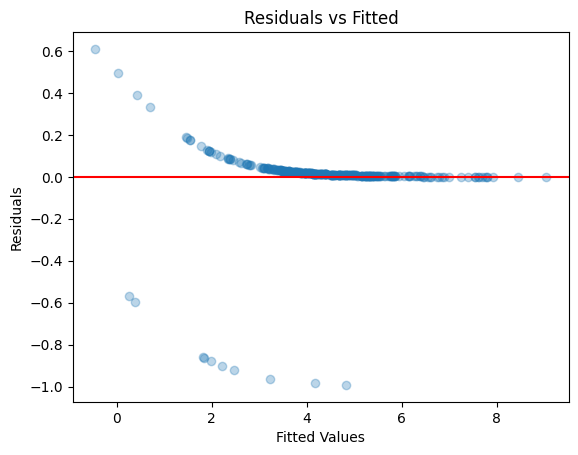

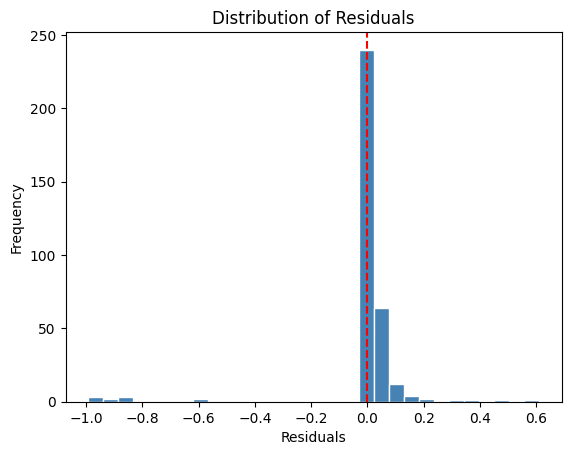

In [ ]:
fitted = baseline.fittedvalues
residuals = baseline.resid_response
plt.scatter(fitted, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# distribution of residuals:
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

In [ ]:
# robustness check with H1
q99 = df['RPWG'].quantile(0.99)
df_trim = df[df['RPWG'] <= q99]
robust_check = smf.logit('LFP ~ RPWG + WE + KL6 + FAMINC', data=df_trim).fit(cov_type='HC1')
print(robust_check.get_margeff().summary())

# robustness check with H3
robust_hc3 = smf.logit(formula='LFP ~ RPWG + WE + KL6 + FAMINC',data=df).fit(cov_type='HC3')
print(robust_hc3.get_margeff().summary())


Optimization terminated successfully.
         Current function value: 0.102562
         Iterations 9
        Logit Marginal Effects       
Dep. Variable:                    LFP
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
RPWG           0.0178      0.008      2.275      0.023       0.002       0.033
WE            -0.0051      0.004     -1.393      0.164      -0.012       0.002
KL6           -0.0495      0.017     -2.835      0.005      -0.084      -0.015
FAMINC     -2.078e-07   7.45e-07     -0.279      0.780   -1.67e-06    1.25e-06
Optimization terminated successfully.
         Current function value: 0.102562
         Iterations 9
        Logit Marginal Effects       
Dep. Variable:                    LFP
Method:                          dydx
At:                           overall
                dy